# Bat pregnancy study - Exploratory Data Analysis

This notebook explores PIT-tag (Trovan RFID) detection data collected at bat boxes over
**5 nights (14-18 May 2024)**. The raw logger exports from 13 recording sessions were
merged into a single clean CSV (`data/combined_data.csv`) by `data/merge_csv.py`.

**Data cleaning notes**
- One clean `date` column: the logger's date is used where valid; for the 192 rows with
  corrupted logger dates (2 reader sessions on 16 May), the filename date is used and the
  post-midnight rows are assigned to the next day.
- Empty / constant columns were dropped. Final columns:
  `date, colony, box, logger, species, details, Transponder Code:, Time:`.
- Species: `Mbec` = *Myotis bechsteinii* (Bechstein's bat), the only species present.

**Research context** (see `docs/gyad134.pdf`): PIT-tag detection patterns at maternity
roosts can be used to infer reproductive status and parturition date. During gestation,
females typically leave and return to the roost **once per night**; during lactation, they
do so **several times per night**. So the number of "visits" per bat per night is a key
behavioural signal.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# Locate the merged CSV (works when running from the repo root or notebooks/)
candidates = ["data/combined_data.csv", "../data/combined_data.csv", "combined_data.csv"]
data_path = next((c for c in candidates if os.path.exists(c)), None)
if data_path is None:
    raise FileNotFoundError("combined_data.csv not found - run data/merge_csv.py first")

df = pd.read_csv(data_path, dtype=str)

# Parse dates / times
df["date"] = pd.to_datetime(df["date"])
df["datetime"] = pd.to_datetime(df["date"].dt.strftime("%Y-%m-%d") + " " + df["Time:"])
df["hour"] = df["datetime"].dt.hour

print(f"Loaded {len(df)} rows from {data_path}")
df.head()

Loaded 997 rows from ../data/combined_data.csv


,date,colony,box,logger,species,details,Transponder Code:,Time:,datetime,hour
0,2024-05-14,GB2,K46,LID31,Mbec,empty,00079ABB95,09:27:49,2024-05-14 09:27:49,9
1,2024-05-14,GB2,K46,LID31,Mbec,empty,0006E24ECA,21:36:06,2024-05-14 21:36:06,21
2,2024-05-14,GB2,K46,LID31,Mbec,empty,0007D1088C,21:37:18,2024-05-14 21:37:18,21
3,2024-05-14,GB2,K46,LID31,Mbec,empty,0007D1088C,21:37:19,2024-05-14 21:37:19,21
4,2024-05-14,GB2,K46,LID31,Mbec,empty,0007D104DB,21:37:34,2024-05-14 21:37:34,21


## 1. Dataset overview

Let's look at the basic shape of the data: how many detections, individuals, boxes,
loggers and which time span is covered. Detections here are raw logger hits - a bat
passing a reader antenna is typically registered several times in quick succession, so
raw counts over-represent "presence". We separate the two in section 5.


In [2]:
print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"Rows:                    {len(df)}")
print(f"Time span:               {df['date'].min().date()}  to  {df['date'].max().date()}")
print(f"Unique bats (PIT tags):  {df['Transponder Code:'].nunique()}")
print(f"Boxes:                   {', '.join(sorted(df['box'].unique()))}")
print(f"Loggers:                 {', '.join(sorted(df['logger'].unique()))}")
print(f"Species:                 {', '.join(df['species'].unique())}")
print()
print("Missing values per column:")
print(df.isna().sum().to_string())
print()
print("Rows per (box, logger):")
print(df.groupby(["box", "logger"]).size().to_string())

DATASET OVERVIEW
Rows:                    997
Time span:               2024-05-14  to  2024-05-19
Unique bats (PIT tags):  68
Boxes:                   K37, K44, K46, K81, K84, K89, K9
Loggers:                 LID31, LID32, LID37
Species:                 Mbec

Missing values per column:
date                 0
colony               0
box                  0
logger               0
species              0
details              0
Transponder Code:    0
Time:                0
datetime             0
hour                 0

Rows per (box, logger):
box  logger
K37  LID32     110
K44  LID32     160
K46  LID31      42
K81  LID37     150
K84  LID37      47
K89  LID31     478
K9   LID37      10


## 2. Activity over time

Bats are nocturnal. Two things to look for here:

1. **Coverage**: which nights have data, and is the effort balanced?
2. **Activity pattern**: when are bats moving through the box entrances?

The heatmap at the end combines both - it shows exactly which hours of which night
produced detections.


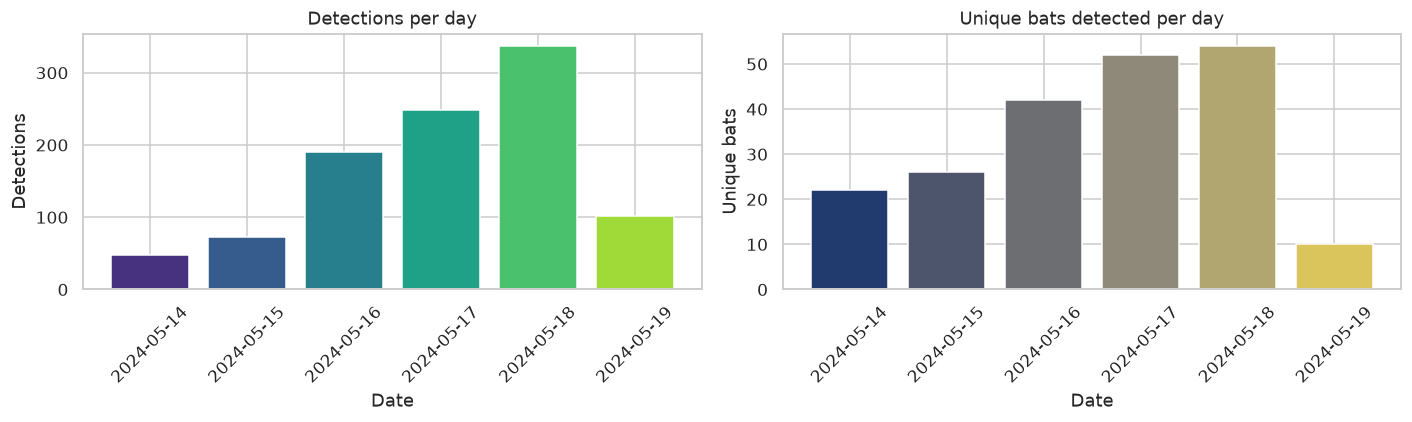

In [3]:
per_day = df.groupby(df["date"].dt.date).size()
bats_day = df.groupby(df["date"].dt.date)["Transponder Code:"].nunique()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

c1 = sns.color_palette("viridis", len(per_day))
axes[0].bar([str(d) for d in per_day.index], per_day.values, color=c1)
axes[0].set_title("Detections per day")
axes[0].set_xlabel("Date"); axes[0].set_ylabel("Detections")
axes[0].tick_params(axis="x", rotation=45)

c2 = sns.color_palette("cividis", len(bats_day))
axes[1].bar([str(d) for d in bats_day.index], bats_day.values, color=c2)
axes[1].set_title("Unique bats detected per day")
axes[1].set_xlabel("Date"); axes[1].set_ylabel("Unique bats")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout(); plt.show()

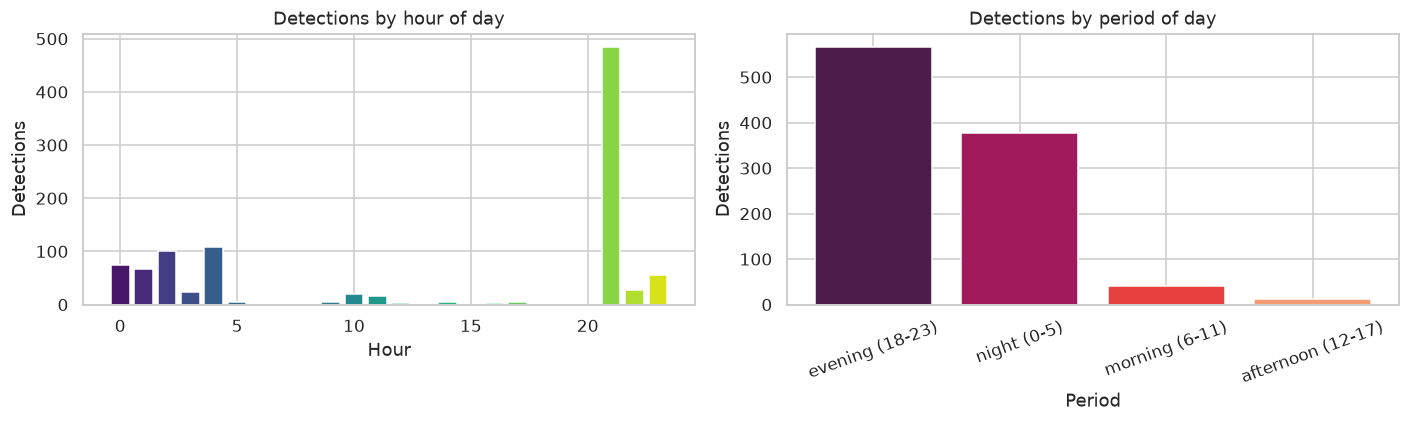

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

hour_counts = df["hour"].value_counts().sort_index()
axes[0].bar(hour_counts.index, hour_counts.values,
            color=sns.color_palette("viridis", len(hour_counts)))
axes[0].set_title("Detections by hour of day")
axes[0].set_xlabel("Hour"); axes[0].set_ylabel("Detections")

df["period"] = pd.cut(df["hour"], bins=[-0.5, 5.5, 11.5, 17.5, 23.5],
                      labels=["night (0-5)", "morning (6-11)",
                              "afternoon (12-17)", "evening (18-23)"])
period_counts = df["period"].value_counts().reindex(
    ["evening (18-23)", "night (0-5)", "morning (6-11)", "afternoon (12-17)"])
axes[1].bar(period_counts.index, period_counts.values,
            color=sns.color_palette("rocket", len(period_counts)))
axes[1].set_title("Detections by period of day")
axes[1].set_xlabel("Period"); axes[1].set_ylabel("Detections")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout(); plt.show()

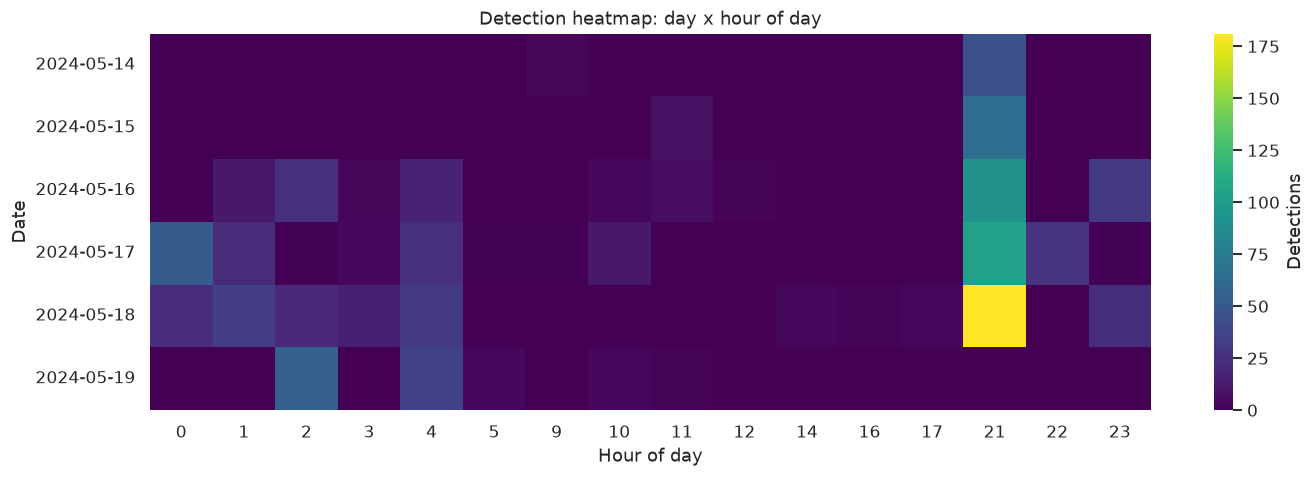

In [5]:
pivot_hour_day = df.pivot_table(index=df["date"].dt.date, columns="hour",
                                values="Transponder Code:", aggfunc="count", fill_value=0)
fig, ax = plt.subplots(figsize=(13, 4.5))
sns.heatmap(pivot_hour_day, ax=ax, cmap="viridis", cbar_kws={"label": "Detections"})
ax.set_title("Detection heatmap: day x hour of day")
ax.set_xlabel("Hour of day"); ax.set_ylabel("Date")
plt.tight_layout(); plt.show()

**What we see**
- Detections cluster in **two windows**: around **21:00-23:00** (evening, when bats leave
  and return at dusk) and around **00:00-05:00** (post-midnight activity, with a secondary
  peak near 04:00-05:00, i.e. pre-dawn returns).
- There is a small morning component (09:00-11:00) that belongs to the tail of the
  previous night's session.
- The day-by-day totals grow towards the end of the week (337 detections on 18 May vs 48 on
  14 May), with a morning tail of 101 detections on 19 May from the last night's session.
  Two effects are mixed here: more boxes monitored later in the week, and possibly a growing
  colony. The box x day heatmaps below separate these effects.


## 3. Boxes, loggers and box state ("details")

Seven boxes were monitored, each by a fixed logger. Boxes were monitored on different
nights (K46/K9 only on 14 May, K84 on 15 May, K44 only on 18 May, while K89 ran almost
every night). The `details` column marks whether the box session was recorded as
**TQ** (occupied / part of a used quarter) or **empty**.

Interpretation of raw counts across boxes is therefore only meaningful **per monitored
night**; the heatmaps give the fair view.


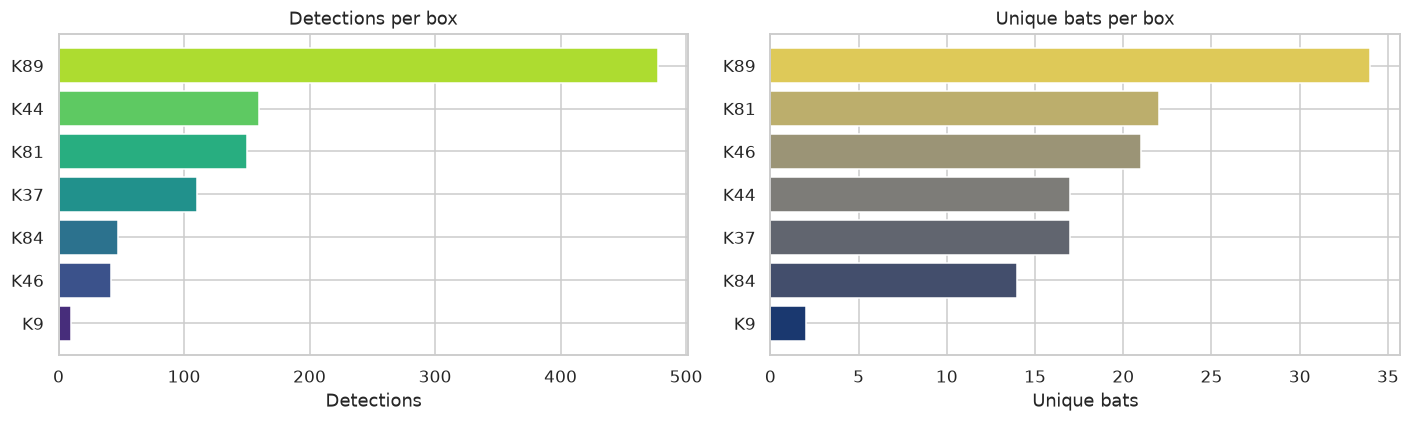

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

box_counts = df["box"].value_counts().sort_values(ascending=True)
axes[0].barh(box_counts.index, box_counts.values,
             color=sns.color_palette("viridis", len(box_counts)))
axes[0].set_title("Detections per box")
axes[0].set_xlabel("Detections")

box_bats = df.groupby("box")["Transponder Code:"].nunique().sort_values(ascending=True)
axes[1].barh(box_bats.index, box_bats.values,
             color=sns.color_palette("cividis", len(box_bats)))
axes[1].set_title("Unique bats per box")
axes[1].set_xlabel("Unique bats")

plt.tight_layout(); plt.show()

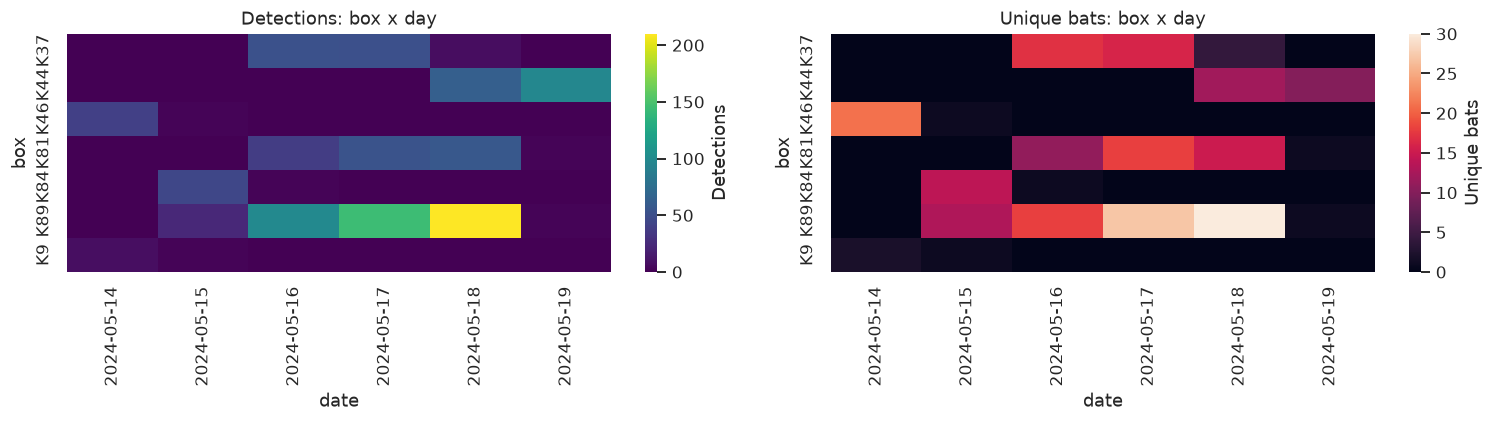

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

p_det = df.pivot_table(index="box", columns=df["date"].dt.date,
                       values="Transponder Code:", aggfunc="count", fill_value=0)
sns.heatmap(p_det, ax=axes[0], cmap="viridis", cbar_kws={"label": "Detections"})
axes[0].set_title("Detections: box x day")

p_bat = df.pivot_table(index="box", columns=df["date"].dt.date,
                       values="Transponder Code:", aggfunc=lambda x: x.nunique(),
                       fill_value=0)
sns.heatmap(p_bat, ax=axes[1], cmap="rocket", cbar_kws={"label": "Unique bats"})
axes[1].set_title("Unique bats: box x day")

plt.tight_layout(); plt.show()

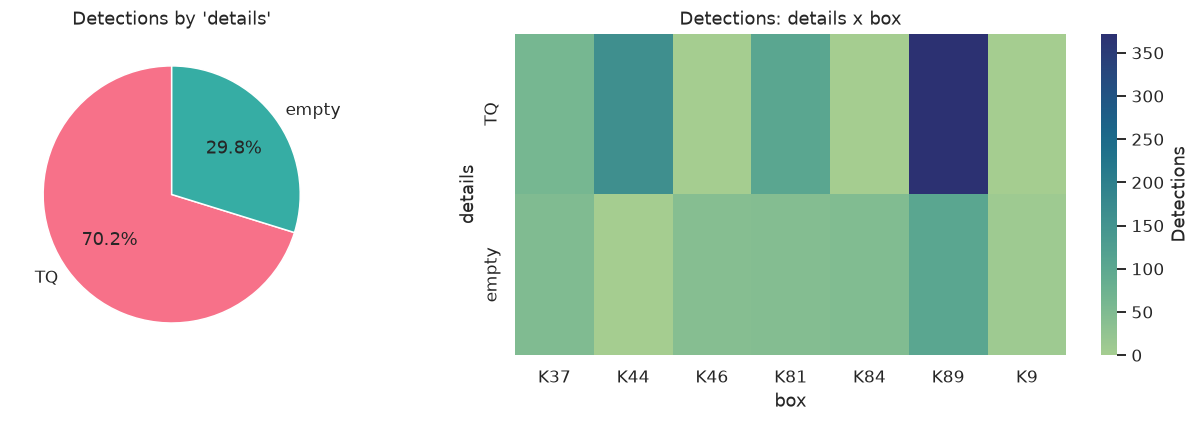

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

det_counts = df["details"].value_counts()
axes[0].pie(det_counts.values, labels=det_counts.index, autopct="%1.1f%%",
            colors=sns.color_palette("husl", 2), startangle=90,
            wedgeprops={"edgecolor": "white"})
axes[0].set_title("Detections by 'details'")

pivot_det = df.pivot_table(index="details", columns="box", values="Transponder Code:",
                           aggfunc="count", fill_value=0)
sns.heatmap(pivot_det, ax=axes[1], cmap="crest", cbar_kws={"label": "Detections"})
axes[1].set_title("Detections: details x box")

plt.tight_layout(); plt.show()

**What we see**
- **K89 is the busiest box** (478 detections, 34 unique bats) and was monitored on 4 of the
  5 nights. K46 is striking: monitored only on 14 May, it still logged **21 unique bats**
  in a single night - a high-density roost box.
- K37 was monitored on 16-17 May (first TQ, then empty). K81 and K89 were switched
  between TQ and empty across nights, so the `details` label describes the box state per
  session, not the box identity.
- Sessions labelled **TQ** produced 70% of detections, but that partly reflects which
  nights they were recorded on.


## 4. The individuals (68 tagged bats)

Each transponder code is one individual. Key questions:
- How many detections does a typical bat accumulate?
- Which individuals are most active / most mobile (moving between boxes)?
- Is every bat detected every night?

Note that detection *count* per bat is strongly influenced by the logger's antenna
placement and the bat's behaviour (how often it passes the antenna), not only by how
often the bat is present.


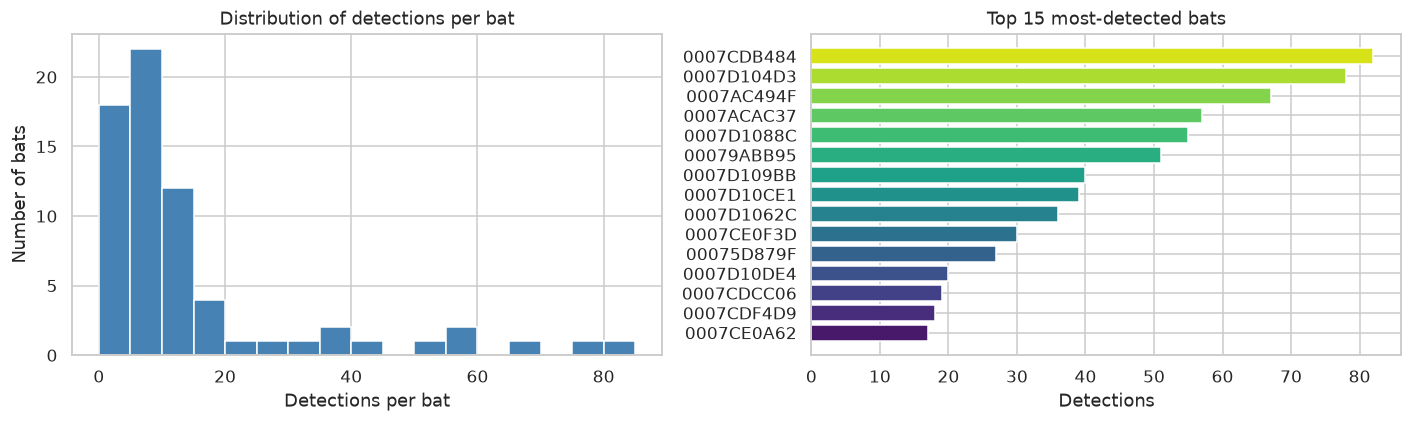

In [9]:
bat_counts = df["Transponder Code:"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(bat_counts.values, bins=range(0, bat_counts.max() + 5, 5),
             color="steelblue", edgecolor="white")
axes[0].set_title("Distribution of detections per bat")
axes[0].set_xlabel("Detections per bat"); axes[0].set_ylabel("Number of bats")

top = bat_counts.head(15).sort_values()
axes[1].barh(top.index, top.values, color=sns.color_palette("viridis", len(top)))
axes[1].set_title("Top 15 most-detected bats")
axes[1].set_xlabel("Detections")

plt.tight_layout(); plt.show()

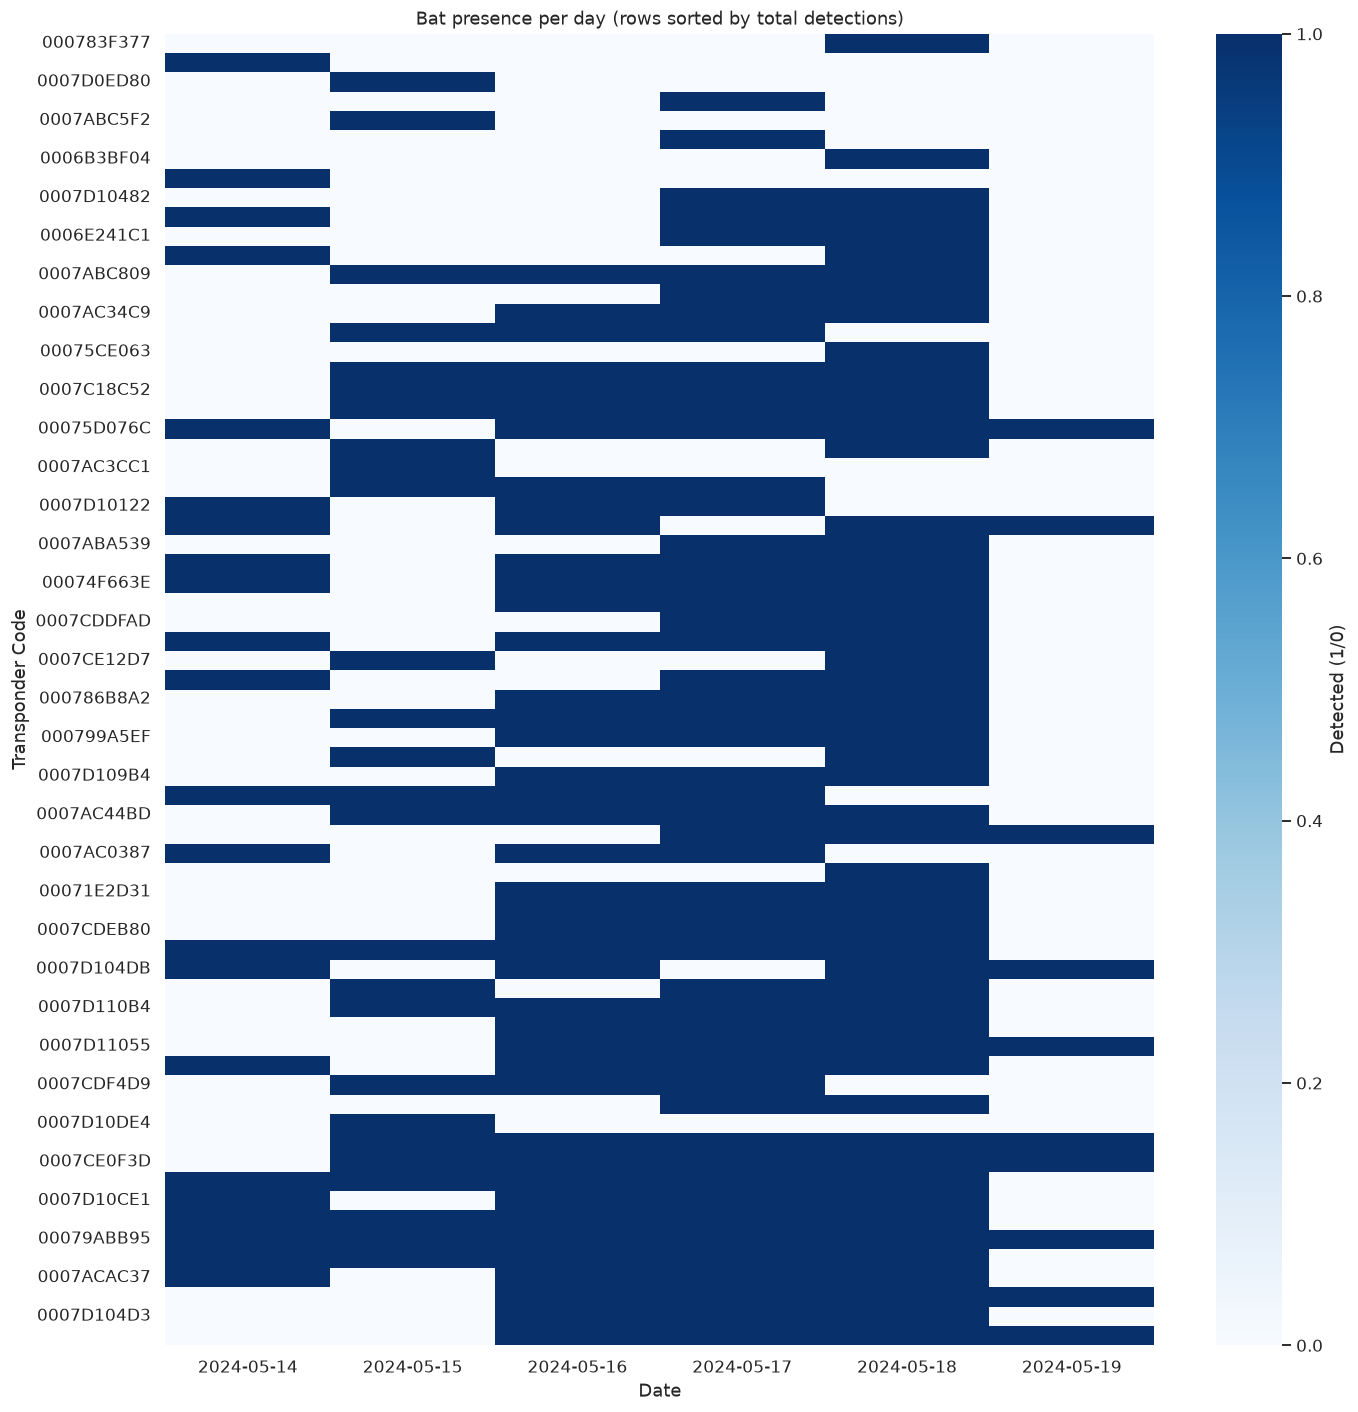

In [10]:
presence = df.pivot_table(index="Transponder Code:", columns=df["date"].dt.date,
                          values="box", aggfunc="count", fill_value=0)
presence = presence.loc[presence.sum(axis=1).sort_values().index]  # sort by total

fig, ax = plt.subplots(figsize=(13, 13))
sns.heatmap((presence > 0).astype(int), ax=ax, cmap="Blues",
            cbar_kws={"label": "Detected (1/0)"})
ax.set_title("Bat presence per day (rows sorted by total detections)")
ax.set_xlabel("Date"); ax.set_ylabel("Transponder Code")
plt.tight_layout(); plt.show()

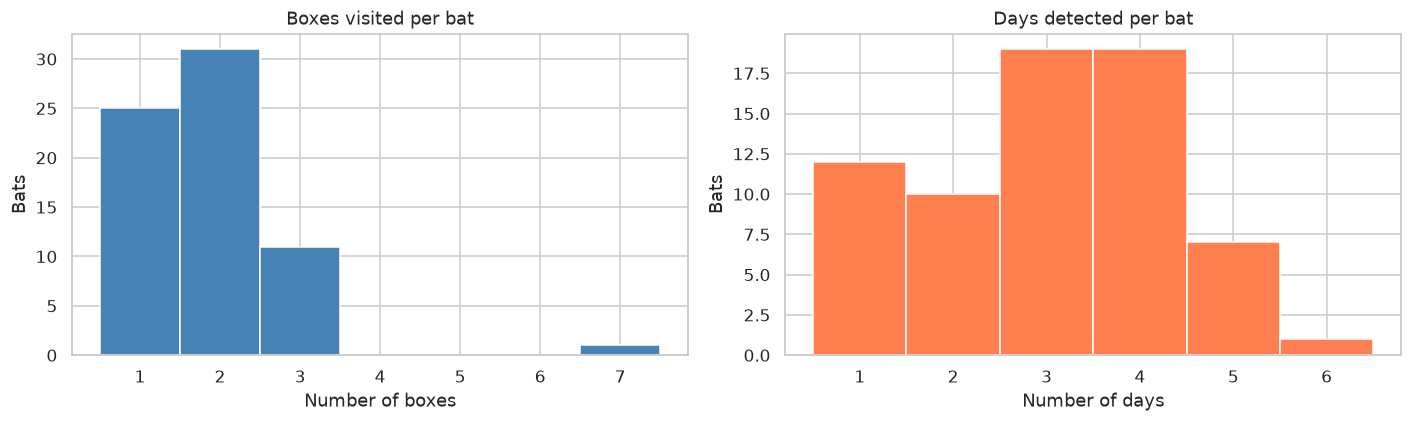

In [11]:
n_boxes = df.groupby("Transponder Code:")["box"].nunique()
n_days = df.groupby("Transponder Code:")["date"].nunique()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(n_boxes.values, bins=np.arange(1, n_boxes.max() + 2) - 0.5,
             color="steelblue", edgecolor="white")
axes[0].set_title("Boxes visited per bat")
axes[0].set_xlabel("Number of boxes"); axes[0].set_ylabel("Bats")

axes[1].hist(n_days.values, bins=np.arange(1, n_days.max() + 2) - 0.5,
             color="coral", edgecolor="white")
axes[1].set_title("Days detected per bat")
axes[1].set_xlabel("Number of days"); axes[1].set_ylabel("Bats")

plt.tight_layout(); plt.show()

In [12]:
mobile = (df.groupby("Transponder Code:")
          .agg(boxes=("box", "nunique"),
               loggers=("logger", "nunique"),
               days=("date", "nunique"),
               detections=("Transponder Code:", "size"))
          .reset_index())
print("Most mobile bats (visited the most boxes/loggers):")
print(mobile.sort_values(["boxes", "loggers", "detections"], ascending=False)
      .head(12).to_string(index=False))

Most mobile bats (visited the most boxes/loggers):
Transponder Code:  boxes  loggers  days  detections
       00079ABB95      7        3     6          51
       0007CDB484      3        2     4          82
       0007D109BB      3        2     5          40
       0007D10CE1      3        2     4          39
       0007CE0F3D      3        2     5          30
       00075D879F      3        2     5          27
       0007D104DB      3        2     4          13
       0007C1922C      3        2     4           7
       00074F663E      3        2     4           6
       0007AC418B      3        2     4           6
       00075D076C      3        2     5           5
       0007D1062C      3        1     5          36


**What we see**
- Median bat is detected **8 times** over the week; the top bat (`0007CDB484`) reaches 82.
- Many bats are detected on **3-4 of the 5 nights**, and most bats move between **2-3 boxes**.
  One individual (`00079ABB95`) was logged at **all 7 boxes, all 3 loggers, on all 5 nights** -
  the most mobile bat in the sample.
- The presence heatmap shows a fairly stable core colony with some visitors that only
  appear once or twice.


## 5. Behaviour: visit events (separating "passes" from raw hits)

A bat passing the reader antenna produces a **burst** of consecutive detections. To count
*visits* (which is what the parturition study needs: number of exits/returns per night),
we merge consecutive detections of the **same bat** that are **<= 60 s apart** into one
"visit event". Each event is one pass through the box entrance.


In [13]:
df = df.sort_values(["Transponder Code:", "datetime"]).reset_index(drop=True)
changed = (df["Transponder Code:"] != df["Transponder Code:"].shift()) | \
          ((df["datetime"] - df["datetime"].shift()).dt.total_seconds() > 60)
df["event_id"] = changed.cumsum()

events = (df.groupby("event_id", as_index=False)
            .agg(code=("Transponder Code:", "first"),
                 start=("datetime", "min"),
                 end=("datetime", "max"),
                 n=("datetime", "size"),
                 box=("box", "first"),
                 logger=("logger", "first")))
events["duration_s"] = (events["end"] - events["start"]).dt.total_seconds()
events["start_hour"] = events["start"].dt.hour

print(f"Total visit events (same bat, gaps <= 60 s): {len(events)}")
print(f"Detections per event -> median {events['n'].median():.0f}, "
      f"mean {events['n'].mean():.2f}, max {events['n'].max():.0f}")
print(f"Event duration       -> median {events['duration_s'].median():.0f} s, "
      f"max {events['duration_s'].max():.0f} s")

Total visit events (same bat, gaps <= 60 s): 353
Detections per event -> median 1, mean 2.82, max 39
Event duration       -> median 0 s, max 114 s


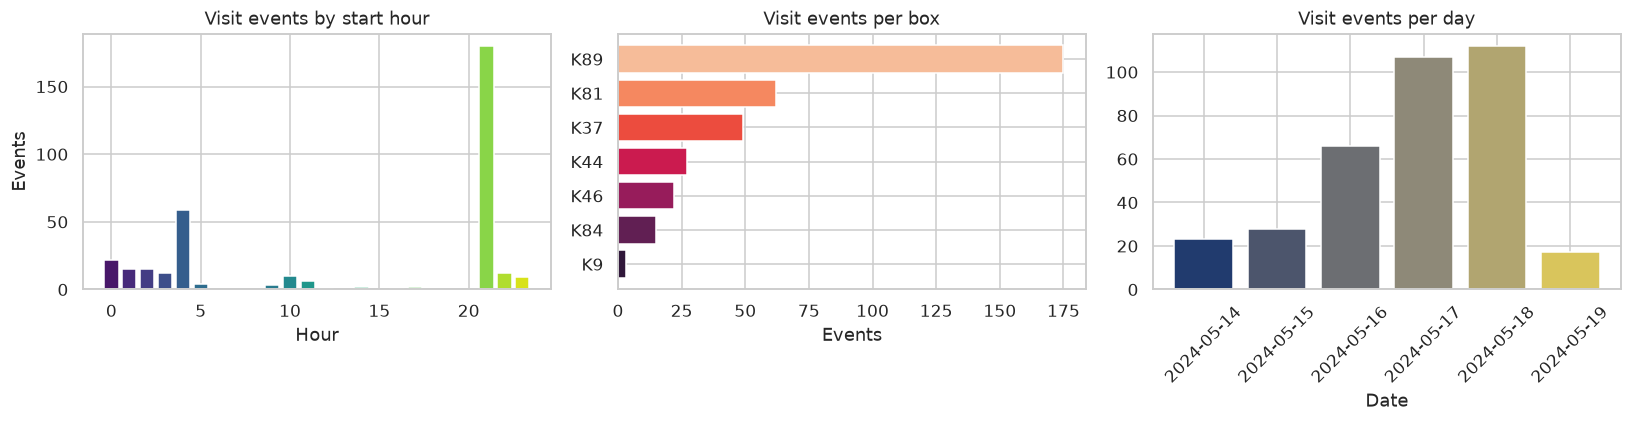

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

eh = events["start_hour"].value_counts().sort_index()
axes[0].bar(eh.index, eh.values, color=sns.color_palette("viridis", len(eh)))
axes[0].set_title("Visit events by start hour")
axes[0].set_xlabel("Hour"); axes[0].set_ylabel("Events")

eb = events.groupby("box").size().sort_values(ascending=True)
axes[1].barh(eb.index, eb.values, color=sns.color_palette("rocket", len(eb)))
axes[1].set_title("Visit events per box")
axes[1].set_xlabel("Events")

ed = events.groupby(events["start"].dt.date).size().sort_index()
axes[2].bar([str(d) for d in ed.index], ed.values,
            color=sns.color_palette("cividis", len(ed)))
axes[2].set_title("Visit events per day")
axes[2].set_xlabel("Date"); axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout(); plt.show()

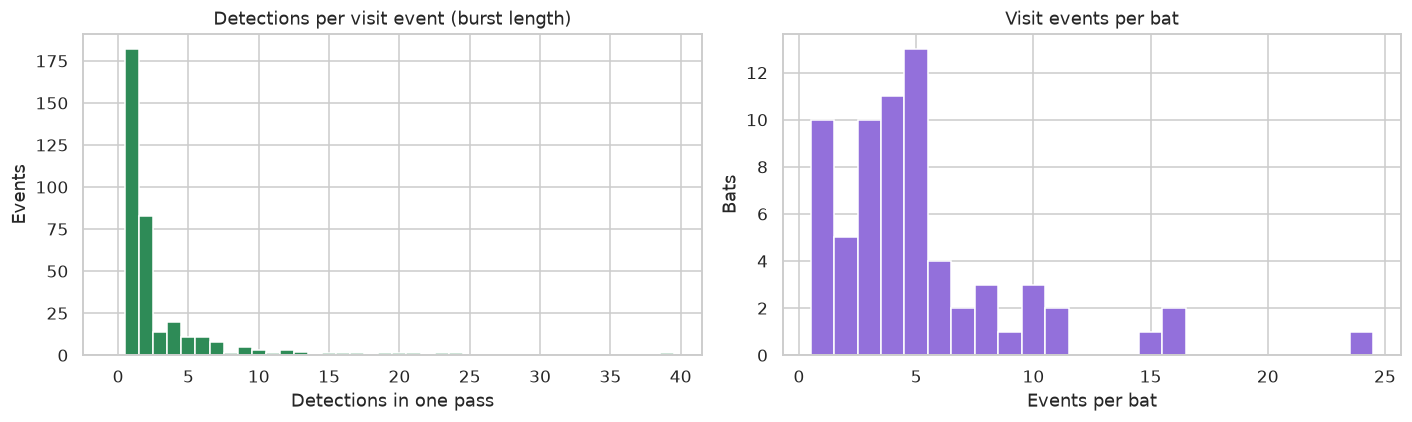

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(events["n"], bins=np.arange(0, events["n"].max() + 2) - 0.5,
             color="seagreen", edgecolor="white")
axes[0].set_title("Detections per visit event (burst length)")
axes[0].set_xlabel("Detections in one pass"); axes[0].set_ylabel("Events")

events_per_bat = events.groupby("code").size()
axes[1].hist(events_per_bat.values,
             bins=np.arange(1, events_per_bat.max() + 2) - 0.5,
             color="mediumpurple", edgecolor="white")
axes[1].set_title("Visit events per bat")
axes[1].set_xlabel("Events per bat"); axes[1].set_ylabel("Bats")

plt.tight_layout(); plt.show()

In [16]:
epd = events.groupby([events["start"].dt.date, "code"]).size().reset_index(name="events")
top_epd = epd.sort_values("events", ascending=False).head(10)
print("Busiest bat-nights (most visit events by one bat in one night):")
print(top_epd.to_string(index=False))

Busiest bat-nights (most visit events by one bat in one night):
     start       code  events
2024-05-16 0007ACAC37       7
2024-05-18 0007D1088C       6
2024-05-18 00079A0255       6
2024-05-17 0007D10CE1       6
2024-05-17 0007D1088C       6
2024-05-17 00079ABB95       6
2024-05-18 0007ACAC37       5
2024-05-18 00079ABB95       5
2024-05-16 00079ABB95       5
2024-05-16 0007D10CE1       4


**What we see**
- The **353 visit events** come from bursts of median length 1 and mean ~2.8 raw
  detections, i.e. most passes are single hits; some long bursts (up to 39 detections)
  suggest a bat lingering at the antenna.
- Event timing mirrors the raw pattern: a clear **evening peak at ~21:00** and a smaller
  **pre-dawn peak at ~04:00**.
- A few bats reach **6-7 visit events in a single night** - exactly the kind of
  multiple-exit signal that the gestation vs lactation analysis in `docs/gyad134.pdf`
  looks for. The next step for the study would be to count exits/entries per bat per night
  from these events.


## 6. Single-bat case study: bat 0007D1088C

So far we looked at the whole colony. Let's zoom in on one individual to see what
single-bat visualizations look like. **0007D1088C** is a good example: a resident of box
**K89** (53 of its 55 detections there), detected on **every one of the 5 nights**, with a
clear evening + post-midnight activity pattern.


In [17]:
bat_code = "0007D1088C"
bat = df[df["Transponder Code:"] == bat_code].copy()

print(f"Detections:            {len(bat)}")
print(f"Nights detected:       {bat['date'].dt.date.nunique()}")
print(f"Boxes:                 {bat['box'].value_counts().to_dict()}")
print(f"Loggers:               {bat['logger'].value_counts().to_dict()}")
print(f"Time of day (hours):   {sorted(bat['hour'].unique())}")

Detections:            55
Nights detected:       5
Boxes:                 {'K89': 53, 'K46': 2}
Loggers:               {'LID31': 55}
Time of day (hours):   [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(21), np.int32(22)]


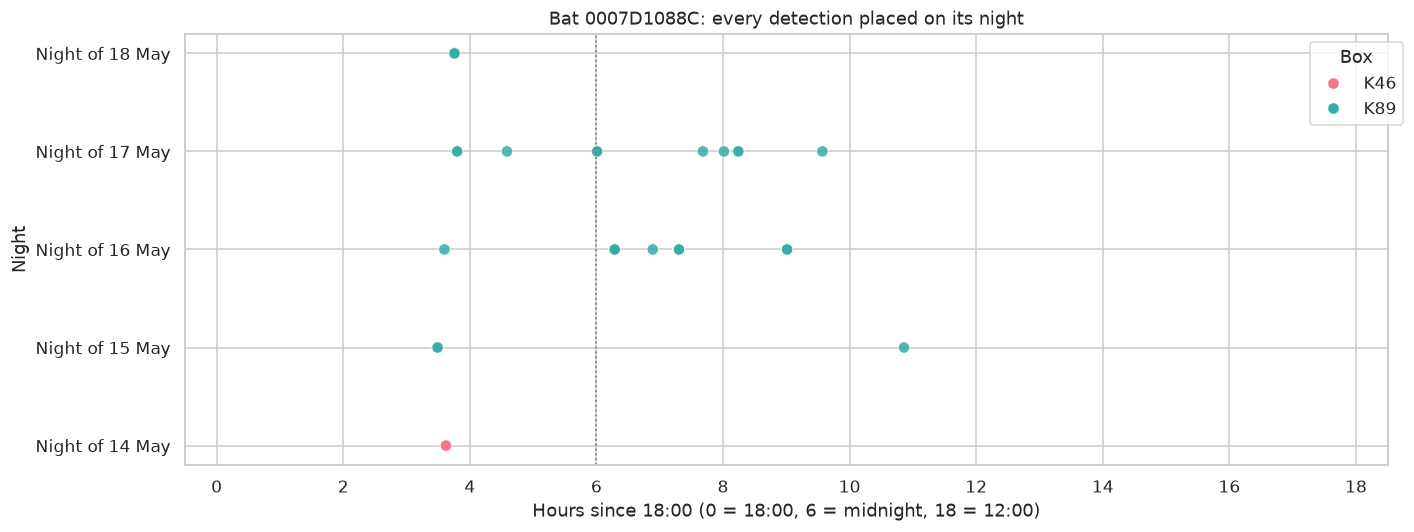

In [18]:
# Night activity: place every detection on its "session night"
# (evening 18:00 of day D -> 12:00 of day D+1, as in the filename convention)
bat_s = bat.sort_values("datetime").copy()
bat_s["night"] = (bat_s["datetime"] - pd.Timedelta(hours=12)).dt.date
night_18 = pd.to_datetime(bat_s["night"].astype(str) + " 18:00:00")
bat_s["hours_since_18"] = (bat_s["datetime"] - night_18).dt.total_seconds() / 3600

box_order = sorted(bat_s["box"].unique())
box_color = dict(zip(box_order, sns.color_palette("husl", len(box_order))))
label = lambda n: "Night of " + pd.to_datetime(n).strftime("%d %b")

fig, ax = plt.subplots(figsize=(13, 5))
for night, grp in bat_s.groupby("night"):
    ax.scatter(grp["hours_since_18"], np.full(len(grp), label(night)),
               s=55, alpha=0.85, edgecolor="white", linewidth=0.5,
               color=[box_color[b] for b in grp["box"]])
ax.axvline(6, color="0.5", ls=":", lw=1.2)   # midnight
ax.set_xlim(-0.5, 18.5)
ax.set_xticks(range(0, 19, 2))
ax.set_xlabel("Hours since 18:00 (0 = 18:00, 6 = midnight, 18 = 12:00)")
ax.set_ylabel("Night")
ax.set_title(f"Bat {bat_code}: every detection placed on its night")
ax.legend(handles=[plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=c,
                              markersize=8, label=b) for b, c in box_color.items()],
          title="Box", bbox_to_anchor=(1.02, 1))
plt.tight_layout(); plt.show()

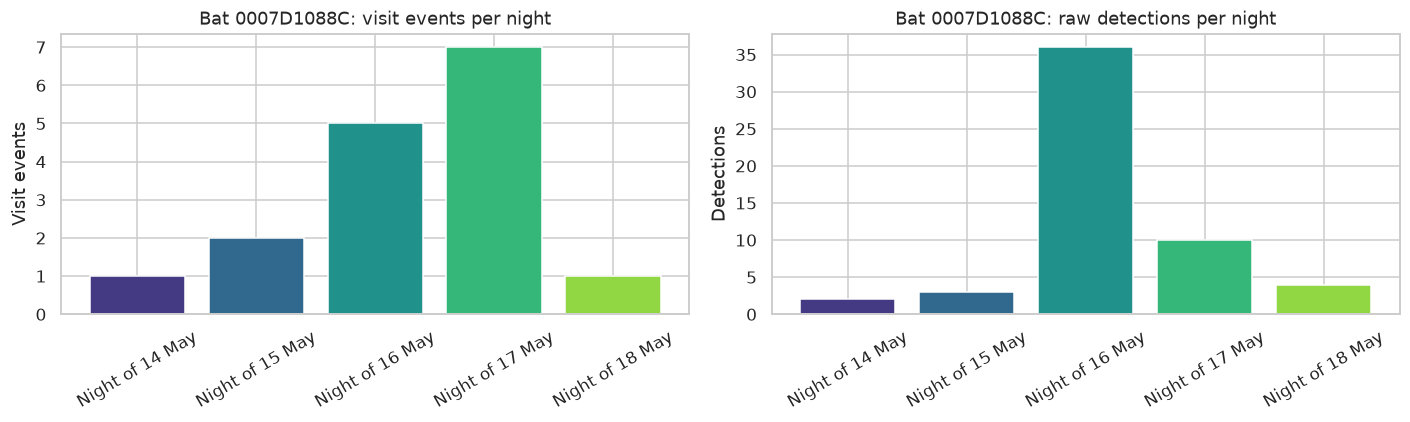

Visit events per night:
night
2024-05-14    1
2024-05-15    2
2024-05-16    5
2024-05-17    7
2024-05-18    1


In [19]:
# Visit events for this bat (merge detections with gaps <= 60 s)
new_event = (bat_s["datetime"] - bat_s["datetime"].shift()).dt.total_seconds() > 60
bat_s["event_id"] = new_event.cumsum()

events_bat = (bat_s.groupby("event_id", as_index=False)
              .agg(start=("datetime", "min"), end=("datetime", "max"),
                   n=("datetime", "size"), box=("box", "first")))
events_bat["night"] = (events_bat["start"] - pd.Timedelta(hours=12)).dt.date

nights = sorted(bat_s["night"].unique())
ev_counts = [events_bat[events_bat["night"] == n].shape[0] for n in nights]
det_counts = [bat_s[bat_s["night"] == n].shape[0] for n in nights]
labels = [label(n) for n in nights]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
c = sns.color_palette("viridis", len(nights))
axes[0].bar(labels, ev_counts, color=c)
axes[0].set_title(f"Bat {bat_code}: visit events per night")
axes[0].set_ylabel("Visit events"); axes[0].tick_params(axis="x", rotation=30)
axes[1].bar(labels, det_counts, color=c)
axes[1].set_title(f"Bat {bat_code}: raw detections per night")
axes[1].set_ylabel("Detections"); axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

print("Visit events per night:")
print(events_bat.groupby("night").size().to_string())

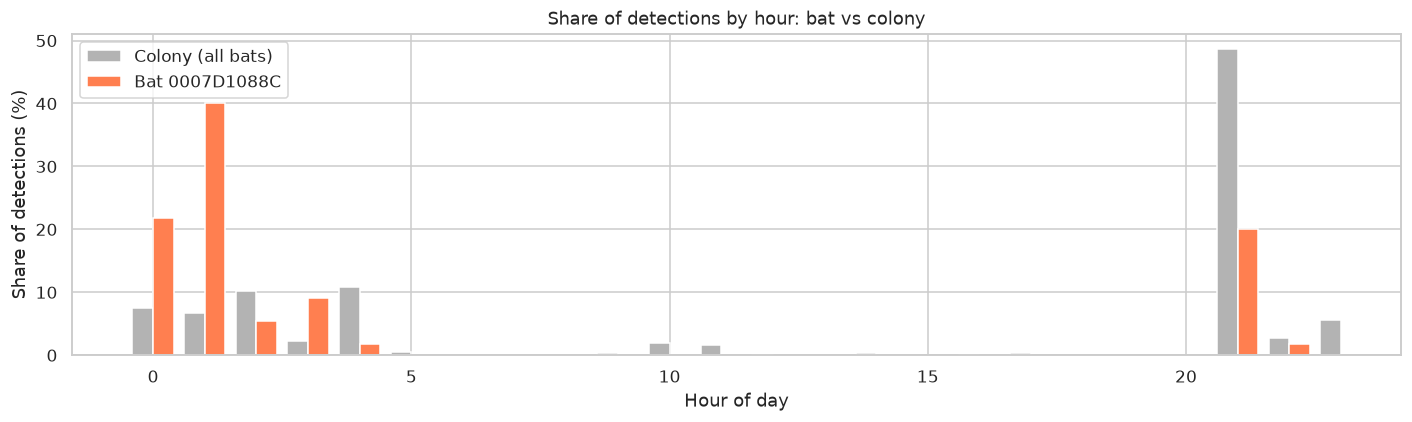

In [20]:
# Hour-of-day signature: bat vs the whole colony
colony_hours = df["hour"].value_counts(normalize=True).sort_index()
bat_hours = bat_s["hour"].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(colony_hours.index - 0.2, colony_hours.values * 100, width=0.4,
       label="Colony (all bats)", color="0.7")
ax.bar(bat_hours.index + 0.2, bat_hours.values * 100, width=0.4,
       label=f"Bat {bat_code}", color="coral")
ax.set_title("Share of detections by hour: bat vs colony")
ax.set_xlabel("Hour of day"); ax.set_ylabel("Share of detections (%)")
ax.legend()
plt.tight_layout(); plt.show()

**What this bat tells us**
- **0007D1088C is a K89 resident**: 53 of its 55 detections are at K89 (it was only
  briefly logged at K46 on the first night), and it was detected every single night.
- **Two activity windows per night**: around 21:00 (evening) and 00:00-04:00
  (post-midnight). The bimodal signature matches the colony average.
- **The number of nightly visit events rises from 1 to 7** over the week (nights 14 to
  17) and then drops back to 1. Going from one nightly excursion to several is exactly the
  kind of behavioural change the parturition study uses to tell gestation from lactation
  (1 exit/night vs several). Five nights is a short window, so this is a pattern to flag
  to the study team, not a conclusion by itself.
- Night 16 stands out: 36 raw detections, including one burst of 21 detections in 22
  seconds - the bat lingered at the antenna.

This section is a template: change `bat_code` above to inspect any other individual, e.g.
`0007CDB484` (most-detected bat, 82 detections) or `00079ABB95` (most mobile, all 7 boxes).


## 7. Summary of findings

1. **Data quality is good after cleaning.** One clean `date` column covers all 997 rows;
   the 192 corrupted logger dates (2 reader sessions on 16 May) were recovered from the
   filename and the midnight roll-over, so no data was lost.
2. **Activity is strongly nocturnal and bimodal.** Detections concentrate at 21:00-23:00
   and 00:00-05:00, with a smaller 09:00-11:00 tail. Almost nothing in the afternoon.
3. **Coverage is uneven across boxes.** K89 dominates (4 nights, 34 bats). K46 shows the
   highest single-night density (21 bats on 14 May). Comparisons across boxes need to
   account for the nights each box was monitored.
4. **68 individuals, mostly resident.** Most bats were detected on 3-5 nights and at 2-3
   boxes; a handful are one-night visitors. `00079ABB95` is exceptionally mobile (all 7
   boxes, all 3 loggers, all 5 nights).
5. **353 visit events** after merging 60 s bursts. Most passes are brief; a few bats make
   up to 6-7 visits in a single night, which is the signal most relevant for inferring
   reproductive state (gestation = 1 exit/night vs lactation = multiple exits/night).

**Natural next steps** (happy to help): build a per-bat-per-night table of visit counts,
exit/entry times and inter-visit gaps, then compare TQ vs empty sessions or track changes
across the 5 nights.
